# Data Understanding - Medical Representatives Performance
## Avatar Project - TDSP Methodology

**Dataset #2:** Medical Representatives Performance Data

**Intérêt:** Ce dataset est crucial pour DSO 1 (évaluation automatique des interactions), DSO 3 (analytics CRM), et DSO 4 (optimisation des tournées)

---
## 1. Load Data

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv('med_rep_performance.csv', encoding='utf-8-sig')

print(f"Dataset loaded: {df.shape[0]} interactions, {df.shape[1]} columns")

Dataset loaded: 800 interactions, 17 columns


---
## 2. First Look at Data

In [8]:
# Show first 5 rows
df.head()

,interaction_id,rep_id,rep_name,date,time,interaction_type,client_name,client_type,product_presented,duration_minutes,governorate,scientific_accuracy_score,communication_clarity_score,objection_handling_score,overall_score,outcome,feedback
0,INT00222,REP019,Fares Guesmi,2025-08-01,14:00,Visite Pharmacie,Pharmacie El Menzah,Pharmacie,PédiaKids Gelée royale,33,Gabès,7.4,7.9,7.3,7.5,Demande Info,Doit améliorer la connaissance produit
1,INT00346,REP015,Zied Laabidi,2025-08-01,11:30,Formation Interne,Formation Interne,Formation,PHYTOFANE Lotion anti chute,152,Ben Arous,5.7,4.5,4.8,5.0,Objections,Présentation structurée et complète
2,INT00422,REP008,Amira Khelifi,2025-08-01,13:15,Visite Pharmacie,Pharmacie El Menzah,Pharmacie,"LV Sélénium A, C, E Anti-âge",30,Monastir,9.2,8.9,7.3,8.5,Intérêt Fort,Besoin de plus de confiance à l'oral
3,INT00398,REP002,Fatma Trabelsi,2025-08-01,09:15,Formation Interne,Formation Interne,Formation,"LV Sélénium A, C, E Anti-âge",99,Monastir,8.9,8.0,9.7,8.9,Intérêt Fort,"Bonne présentation, arguments convaincants"
4,INT00702,REP002,Fatma Trabelsi,2025-08-02,08:00,Visite Pharmacie,Pharmacie Centrale,Pharmacie,"LV Sélénium A, C, E Anti-âge",22,Tunis,9.8,8.4,7.7,8.6,Vente,Très bonne maîtrise technique du produit


In [10]:
# Show dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   interaction_id               800 non-null    object 
 1   rep_id                       800 non-null    object 
 2   rep_name                     800 non-null    object 
 3   date                         800 non-null    object 
 4   time                         800 non-null    object 
 5   interaction_type             800 non-null    object 
 6   client_name                  800 non-null    object 
 7   client_type                  800 non-null    object 
 8   product_presented            800 non-null    object 
 9   duration_minutes             800 non-null    int64  
 10  governorate                  800 non-null    object 
 11  scientific_accuracy_score    800 non-null    float64
 12  communication_clarity_score  800 non-null    float64
 13  objection_handling_s

In [12]:
# Show column names
print("Columns:")
for col in df.columns:
    print(f"  - {col}")

Columns:
  - interaction_id
  - rep_id
  - rep_name
  - date
  - time
  - interaction_type
  - client_name
  - client_type
  - product_presented
  - duration_minutes
  - governorate
  - scientific_accuracy_score
  - communication_clarity_score
  - objection_handling_score
  - overall_score
  - outcome
  - feedback


### Column Descriptions:

| Column | Description |
|--------|-------------|
| **interaction_id** | Unique identifier for each interaction |
| **rep_id** | Medical representative ID |
| **rep_name** | Medical representative name |
| **date** | Date of interaction |
| **time** | Time of interaction |
| **interaction_type** | Type (Visite Pharmacie, Visite Médecin, Formation) |
| **client_name** | Name of pharmacy or doctor |
| **client_type** | Type of client (Pharmacie, Médecin, Formation) |
| **product_presented** | Product presented during interaction |
| **duration_minutes** | Duration of interaction in minutes |
| **governorate** | Governorate (region) of Tunisia |
| **scientific_accuracy_score** | Score for scientific precision (0-10) |
| **communication_clarity_score** | Score for communication clarity (0-10) |
| **objection_handling_score** | Score for handling objections (0-10) |
| **overall_score** | Average of three performance scores |
| **outcome** | Result of interaction (Vente, Intérêt, Refus, etc.) |
| **feedback** | Textual feedback on performance |

---
## 3. Check Data Quality

In [16]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nMissing percentage:")
print((df.isnull().sum() / len(df) * 100).round(1))

Missing Values:
interaction_id                 0
rep_id                         0
rep_name                       0
date                           0
time                           0
interaction_type               0
client_name                    0
client_type                    0
product_presented              0
duration_minutes               0
governorate                    0
scientific_accuracy_score      0
communication_clarity_score    0
objection_handling_score       0
overall_score                  0
outcome                        0
feedback                       0
dtype: int64

Missing percentage:
interaction_id                 0.0
rep_id                         0.0
rep_name                       0.0
date                           0.0
time                           0.0
interaction_type               0.0
client_name                    0.0
client_type                    0.0
product_presented              0.0
duration_minutes               0.0
governorate                    0.0
scie

In [18]:
# Check duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate interaction IDs: {df['interaction_id'].duplicated().sum()}")

Duplicate rows: 0
Duplicate interaction IDs: 0


---
## 4. Analyze Medical Representatives

In [21]:
# Number of reps and interactions per rep
print(f"Total medical representatives: {df['rep_id'].nunique()}")
print(f"\nInteractions per rep:")
print(df['rep_id'].value_counts().describe())

Total medical representatives: 25

Interactions per rep:
count    25.000000
mean     32.000000
std       5.993052
min      21.000000
25%      28.000000
50%      31.000000
75%      36.000000
max      49.000000
Name: count, dtype: float64


In [23]:
# Top 10 most active reps
print("Top 10 Most Active Representatives:")
top_reps = df['rep_name'].value_counts().head(10)
print(top_reps)

Top 10 Most Active Representatives:
rep_name
Tarek Mejri       49
Rami Abidi        39
Sonia Mansouri    39
Nadia Sassi       38
Mohamed Gharbi    38
Leila Cherif      37
Fares Guesmi      36
Ines Mbarek       35
Hajer Toumi       34
Dorra Kilani      34
Name: count, dtype: int64


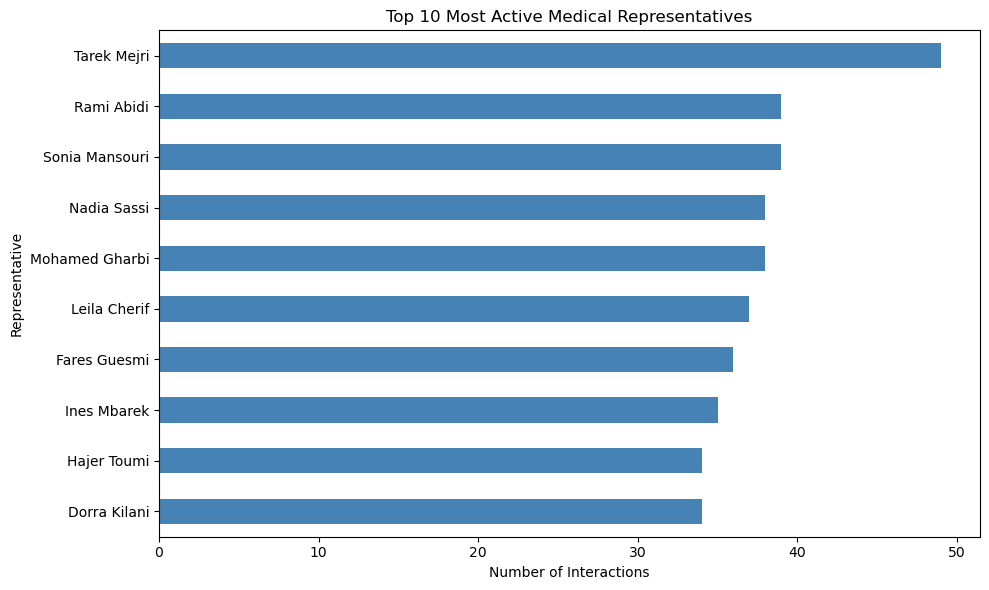

In [25]:
# Visualize top reps
top_reps.plot(kind='barh', color='steelblue', figsize=(10,6))
plt.title('Top 10 Most Active Medical Representatives')
plt.xlabel('Number of Interactions')
plt.ylabel('Representative')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. Analyze Interaction Types

In [28]:
# Count interaction types
print("Interaction Types:")
print(df['interaction_type'].value_counts())
print(f"\nPercentages:")
print((df['interaction_type'].value_counts() / len(df) * 100).round(1))

Interaction Types:
interaction_type
Visite Médecin          206
Présentation Produit    202
Visite Pharmacie        201
Formation Interne       191
Name: count, dtype: int64

Percentages:
interaction_type
Visite Médecin          25.8
Présentation Produit    25.2
Visite Pharmacie        25.1
Formation Interne       23.9
Name: count, dtype: float64


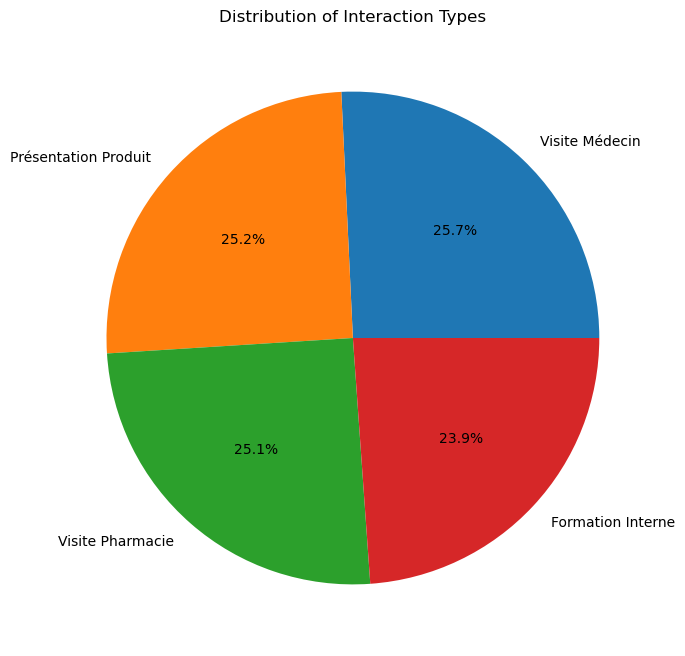

In [30]:
# Visualize interaction types
df['interaction_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8,8))
plt.title('Distribution of Interaction Types')
plt.ylabel('')
plt.show()

In [32]:
# Client types
print("\nClient Types:")
print(df['client_type'].value_counts())


Client Types:
client_type
Formation    393
Médecin      206
Pharmacie    201
Name: count, dtype: int64


---
## 6. Analyze Performance Scores

In [35]:
# Score statistics
score_cols = ['scientific_accuracy_score', 'communication_clarity_score', 
              'objection_handling_score', 'overall_score']

print("Performance Scores Statistics:")
print(df[score_cols].describe())

Performance Scores Statistics:
       scientific_accuracy_score  communication_clarity_score  \
count                 800.000000                   800.000000   
mean                    7.268250                     7.250500   
std                     1.508496                     1.533546   
min                     4.000000                     4.000000   
25%                     6.200000                     6.200000   
50%                     7.500000                     7.500000   
75%                     8.300000                     8.300000   
max                    10.000000                    10.000000   

       objection_handling_score  overall_score  
count                800.000000     800.000000  
mean                   6.608250       7.042875  
std                    1.810491       1.478236  
min                    3.000000       3.900000  
25%                    5.275000       5.700000  
50%                    6.600000       7.100000  
75%                    7.900000       8.

In [37]:
# Average scores by metric
avg_scores = df[score_cols].mean().sort_values(ascending=False)
print("\nAverage Scores by Metric:")
print(avg_scores)


Average Scores by Metric:
scientific_accuracy_score      7.268250
communication_clarity_score    7.250500
overall_score                  7.042875
objection_handling_score       6.608250
dtype: float64


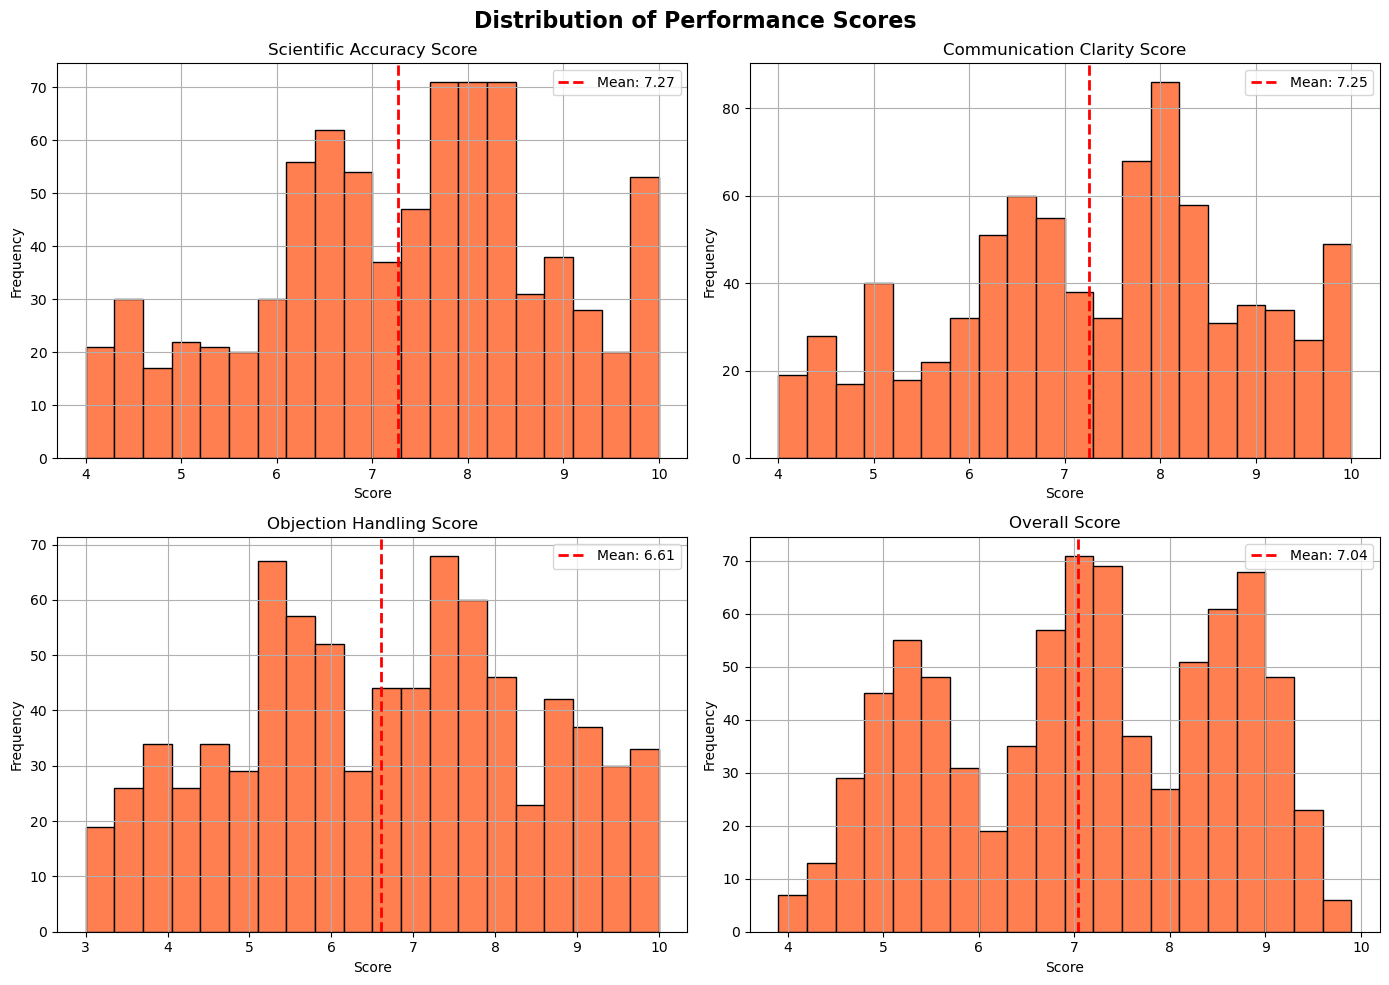

In [39]:
# Visualize score distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Performance Scores', fontsize=16, fontweight='bold')

for idx, col in enumerate(score_cols):
    ax = axes[idx // 2, idx % 2]
    df[col].hist(bins=20, color='coral', edgecolor='black', ax=ax)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

In [41]:
# Score correlation
print("\nScore Correlations:")
print(df[score_cols].corr())


Score Correlations:
                             scientific_accuracy_score  \
scientific_accuracy_score                     1.000000   
communication_clarity_score                   0.728499   
objection_handling_score                      0.752757   
overall_score                                 0.899455   

                             communication_clarity_score  \
scientific_accuracy_score                       0.728499   
communication_clarity_score                     1.000000   
objection_handling_score                        0.767966   
overall_score                                   0.907685   

                             objection_handling_score  overall_score  
scientific_accuracy_score                    0.752757       0.899455  
communication_clarity_score                  0.767966       0.907685  
objection_handling_score                     1.000000       0.929852  
overall_score                                0.929852       1.000000  


---
## 7. Analyze Outcomes

In [44]:
# Outcome distribution
print("Interaction Outcomes:")
print(df['outcome'].value_counts())
print(f"\nPercentages:")
print((df['outcome'].value_counts() / len(df) * 100).round(1))

Interaction Outcomes:
outcome
Demande Info      119
Commande          106
À Recontacter      99
Intérêt Modéré     90
Objections         80
Intérêt Fort       79
Vente              79
Pas Intéressé      78
À Former           70
Name: count, dtype: int64

Percentages:
outcome
Demande Info      14.9
Commande          13.2
À Recontacter     12.4
Intérêt Modéré    11.2
Objections        10.0
Intérêt Fort       9.9
Vente              9.9
Pas Intéressé      9.8
À Former           8.8
Name: count, dtype: float64


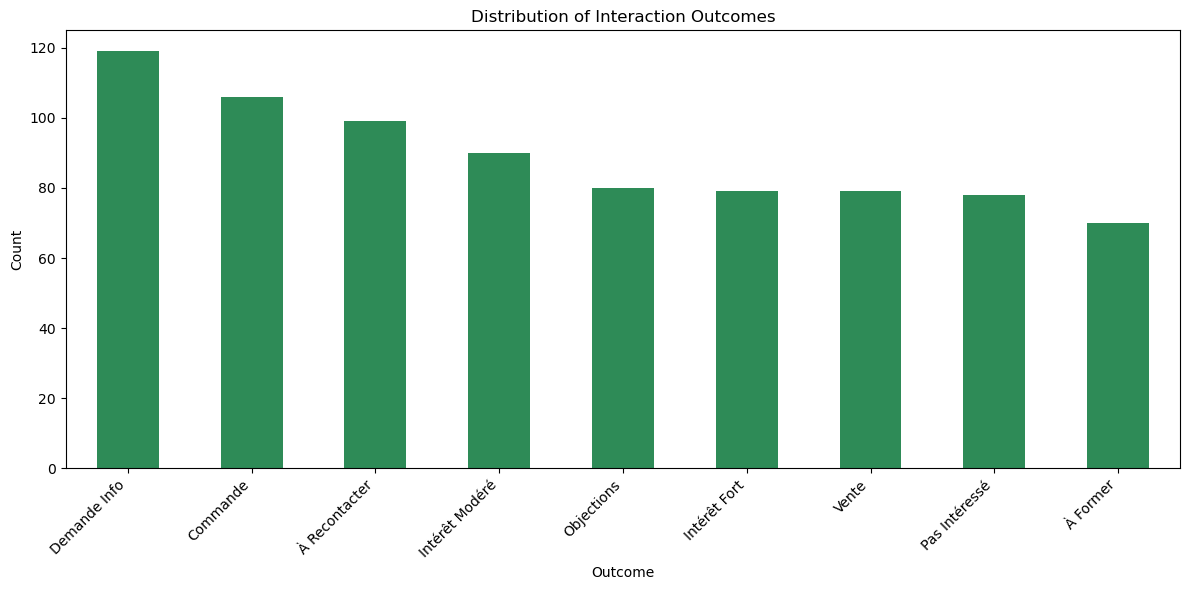

In [46]:
# Visualize outcomes
df['outcome'].value_counts().plot(kind='bar', color='seagreen', figsize=(12,6))
plt.title('Distribution of Interaction Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [48]:
# Average score by outcome
print("\nAverage Overall Score by Outcome:")
score_by_outcome = df.groupby('outcome')['overall_score'].mean().sort_values(ascending=False)
print(score_by_outcome)


Average Overall Score by Outcome:
outcome
Commande          8.753774
Intérêt Fort      8.712658
Vente             8.697468
Intérêt Modéré    7.065556
Demande Info      7.038655
À Recontacter     6.962626
Objections        5.152500
À Former          5.142857
Pas Intéressé     5.076923
Name: overall_score, dtype: float64


---
## 8. Analyze Duration & Time Patterns

In [51]:
# Duration statistics
print("Duration Statistics (minutes):")
print(df['duration_minutes'].describe())

print("\nAverage duration by interaction type:")
print(df.groupby('interaction_type')['duration_minutes'].mean().sort_values(ascending=False))

Duration Statistics (minutes):
count    800.000000
mean      53.662500
std       49.184474
min       10.000000
25%       22.000000
50%       33.000000
75%       45.000000
max      180.000000
Name: duration_minutes, dtype: float64

Average duration by interaction type:
interaction_type
Formation Interne       136.863874
Visite Médecin           28.354369
Visite Pharmacie         27.477612
Présentation Produit     26.856436
Name: duration_minutes, dtype: float64


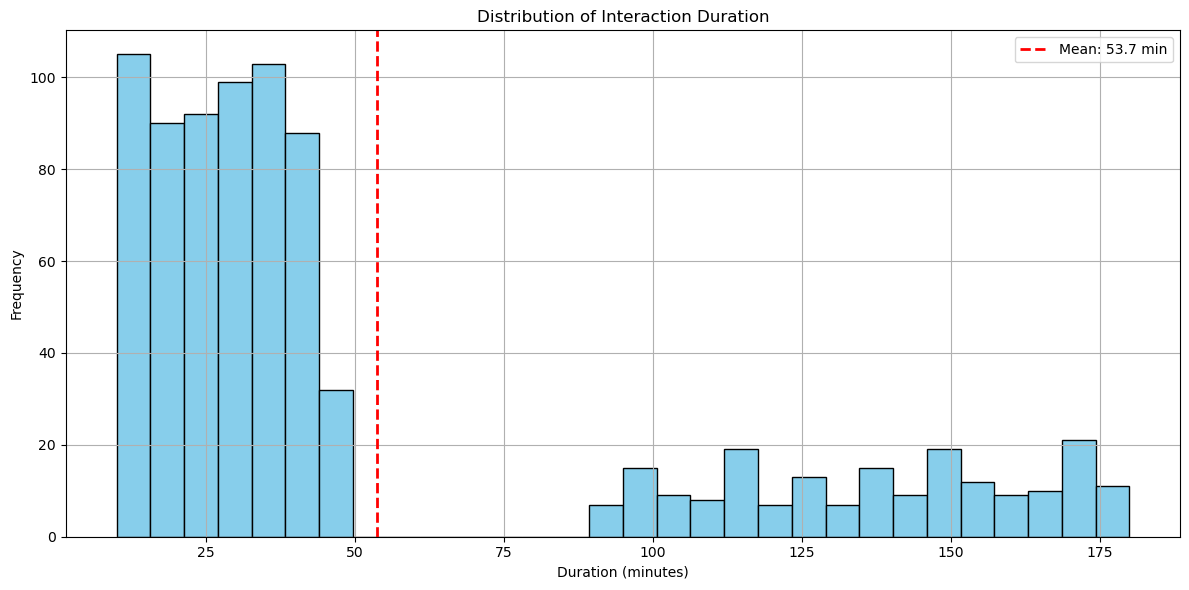

In [53]:
# Duration distribution
plt.figure(figsize=(12, 6))
df['duration_minutes'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Interaction Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.axvline(df['duration_minutes'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["duration_minutes"].mean():.1f} min')
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
# Convert date to datetime and analyze temporal patterns
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()

print("Interactions by Month:")
print(df['month'].value_counts().sort_index())

Interactions by Month:
month
1     135
2      56
8     119
9     115
10    132
11    118
12    125
Name: count, dtype: int64


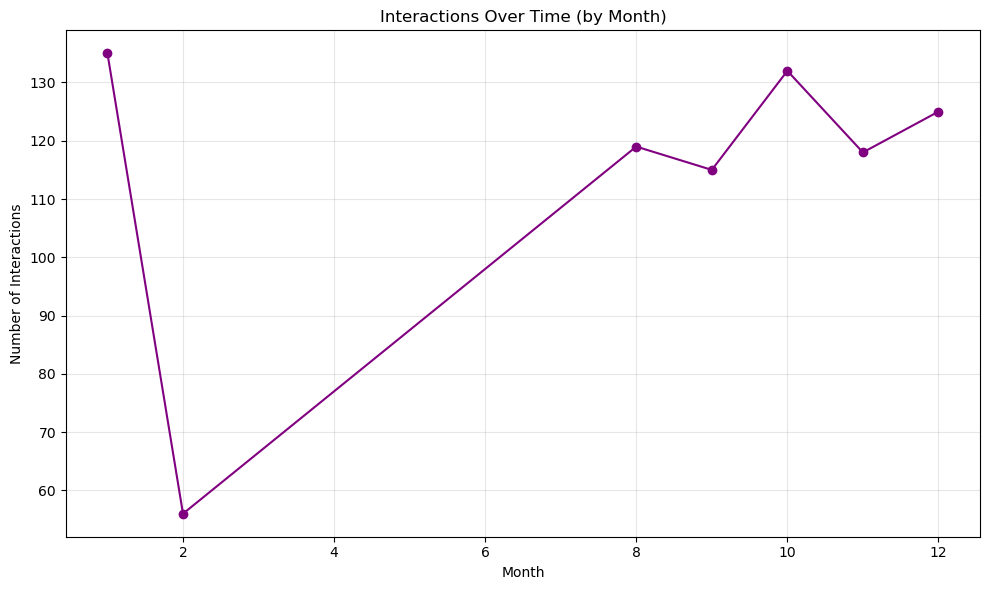

In [57]:
# Interactions over time
interactions_by_month = df.groupby('month').size()
interactions_by_month.plot(kind='line', marker='o', color='purple', figsize=(10,6))
plt.title('Interactions Over Time (by Month)')
plt.xlabel('Month')
plt.ylabel('Number of Interactions')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Analyze Geographic Distribution

In [60]:
# Interactions by governorate
print("Interactions by Governorate:")
print(df['governorate'].value_counts())

Interactions by Governorate:
governorate
Monastir     95
Bizerte      95
Gabès        85
Ariana       81
Tunis        80
Sfax         76
Manouba      75
Nabeul       73
Ben Arous    71
Sousse       69
Name: count, dtype: int64


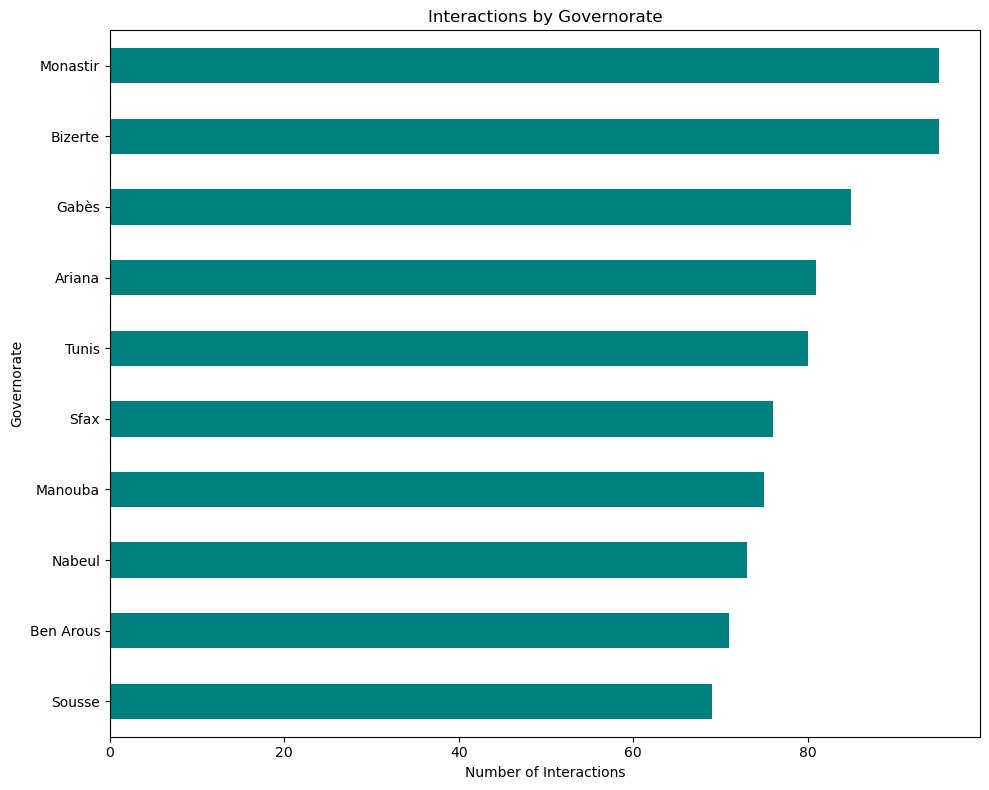

In [62]:
# Visualize geographic distribution
df['governorate'].value_counts().plot(kind='barh', color='teal', figsize=(10,8))
plt.title('Interactions by Governorate')
plt.xlabel('Number of Interactions')
plt.ylabel('Governorate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [64]:
# Average score by governorate
print("\nAverage Performance Score by Governorate:")
score_by_gov = df.groupby('governorate')['overall_score'].mean().sort_values(ascending=False)
print(score_by_gov)


Average Performance Score by Governorate:
governorate
Sousse       7.427536
Nabeul       7.126027
Bizerte      7.125263
Gabès        7.092941
Monastir     7.045263
Tunis        7.022500
Manouba      6.986667
Sfax         6.952632
Ben Arous    6.832394
Ariana       6.829630
Name: overall_score, dtype: float64


---
## 10. Analyze Products

In [67]:
# Most presented products
print("Top 10 Most Presented Products:")
print(df['product_presented'].value_counts().head(10))

Top 10 Most Presented Products:
product_presented
Hydra eau micellaire      67
TC 2000 Nutractiva        66
LV Psolcalm               58
Omevie Omega 3 – 1000     57
Echinacée, Zinc, Vit.C    55
LV Fersang Gélule         55
Vitonic Tonus             54
Huile de Menthe           53
LV CYSPROTECT             52
LV Fersang junior         52
Name: count, dtype: int64


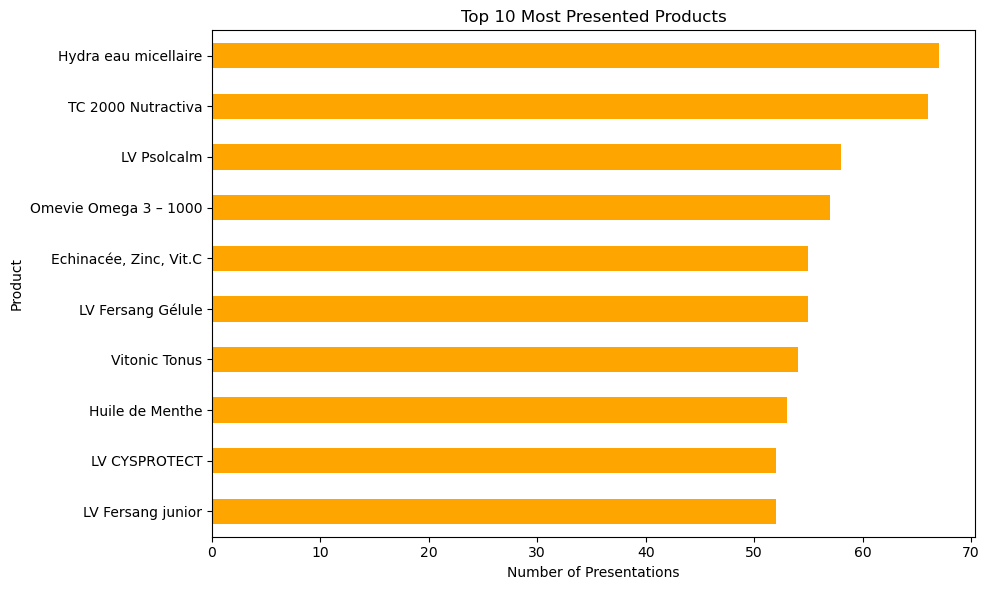

In [69]:
# Visualize top products
df['product_presented'].value_counts().head(10).plot(kind='barh', color='orange', figsize=(10,6))
plt.title('Top 10 Most Presented Products')
plt.xlabel('Number of Presentations')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [71]:
# Average score by product (top 10)
print("\nAverage Score by Product (Top 10 most presented):")
top_products = df['product_presented'].value_counts().head(10).index
score_by_product = df[df['product_presented'].isin(top_products)].groupby('product_presented')['overall_score'].mean().sort_values(ascending=False)
print(score_by_product)


Average Score by Product (Top 10 most presented):
product_presented
Vitonic Tonus             7.418519
Echinacée, Zinc, Vit.C    7.325455
Hydra eau micellaire      7.262687
TC 2000 Nutractiva        7.242424
Huile de Menthe           7.139623
LV Psolcalm               7.043103
Omevie Omega 3 – 1000     7.042105
LV Fersang junior         7.013462
LV CYSPROTECT             6.888462
LV Fersang Gélule         6.543636
Name: overall_score, dtype: float64


---
## 11. Analyze Feedback Text

In [74]:
# Most common feedback
print("Top 10 Most Common Feedback:")
print(df['feedback'].value_counts().head(10))

Top 10 Most Common Feedback:
feedback
Communication claire et professionnelle            89
Très bonne maîtrise technique du produit           87
Excellente gestion des objections                  87
Doit travailler l'écoute active                    85
Besoin de plus de confiance à l'oral               82
Réponses imprécises aux questions scientifiques    81
Doit améliorer la connaissance produit             80
Bonne présentation, arguments convaincants         73
Présentation structurée et complète                72
Manque de précision sur les contre-indications     64
Name: count, dtype: int64


In [76]:
# Sample feedback by score range
print("\nSample Feedback for HIGH performers (score >= 8):")
high_performers = df[df['overall_score'] >= 8][['rep_name', 'overall_score', 'feedback']].head(3)
for idx, row in high_performers.iterrows():
    print(f"  • {row['rep_name']} (Score: {row['overall_score']}): {row['feedback']}")

print("\nSample Feedback for LOW performers (score < 6):")
low_performers = df[df['overall_score'] < 6][['rep_name', 'overall_score', 'feedback']].head(3)
for idx, row in low_performers.iterrows():
    print(f"  • {row['rep_name']} (Score: {row['overall_score']}): {row['feedback']}")


Sample Feedback for HIGH performers (score >= 8):
  • Amira Khelifi (Score: 8.5): Besoin de plus de confiance à l'oral
  • Fatma Trabelsi (Score: 8.9): Bonne présentation, arguments convaincants
  • Fatma Trabelsi (Score: 8.6): Très bonne maîtrise technique du produit

Sample Feedback for LOW performers (score < 6):
  • Zied Laabidi (Score: 5.0): Présentation structurée et complète
  • Bilel Ayari (Score: 4.8): Très bonne maîtrise technique du produit
  • Mehdi Jbeli (Score: 4.2): Doit améliorer la connaissance produit


---
## 12. Rep Performance Ranking

In [79]:
# Calculate average scores per rep
rep_performance = df.groupby(['rep_id', 'rep_name']).agg({
    'overall_score': 'mean',
    'scientific_accuracy_score': 'mean',
    'communication_clarity_score': 'mean',
    'objection_handling_score': 'mean',
    'interaction_id': 'count'
}).round(2)

rep_performance.columns = ['Avg Overall Score', 'Avg Scientific', 'Avg Communication', 'Avg Objections', 'Total Interactions']
rep_performance = rep_performance.sort_values('Avg Overall Score', ascending=False)

print("Top 10 Best Performing Representatives:")
print(rep_performance.head(10))

Top 10 Best Performing Representatives:
                       Avg Overall Score  Avg Scientific  Avg Communication  \
rep_id rep_name                                                               
REP017 Anis Agrebi                  8.77            8.82               8.82   
REP005 Karim Bouaziz                8.75            8.56               8.84   
REP014 Ines Mbarek                  8.72            8.93               8.64   
REP023 Tarek Mejri                  8.71            8.83               8.74   
REP008 Amira Khelifi                8.70            8.49               9.00   
REP011 Rami Abidi                   8.69            8.79               8.93   
REP002 Fatma Trabelsi               8.69            8.64               8.99   
REP020 Nesrine Jaziri               8.47            8.72               8.41   
REP019 Fares Guesmi                 7.21            7.31               7.51   
REP022 Dorra Kilani                 7.07            7.34               7.32   

           

In [81]:
print("\nBottom 10 Representatives (Need Training):")
print(rep_performance.tail(10))


Bottom 10 Representatives (Need Training):
                        Avg Overall Score  Avg Scientific  Avg Communication  \
rep_id rep_name                                                                
REP013 Hichem Dridi                  6.91            7.35               6.86   
REP016 Hajer Toumi                   6.90            7.26               7.08   
REP018 Rim Oueslati                  5.42            5.72               5.74   
REP024 Olfa Haddad                   5.35            5.61               5.77   
REP015 Zied Laabidi                  5.21            5.28               5.68   
REP021 Bilel Ayari                   5.14            5.52               5.62   
REP006 Leila Cherif                  5.12            5.55               5.35   
REP009 Mehdi Jbeli                   5.11            5.59               5.11   
REP003 Mohamed Gharbi                5.07            5.42               5.36   
REP012 Salma Ferchichi               5.00            5.58               5.17

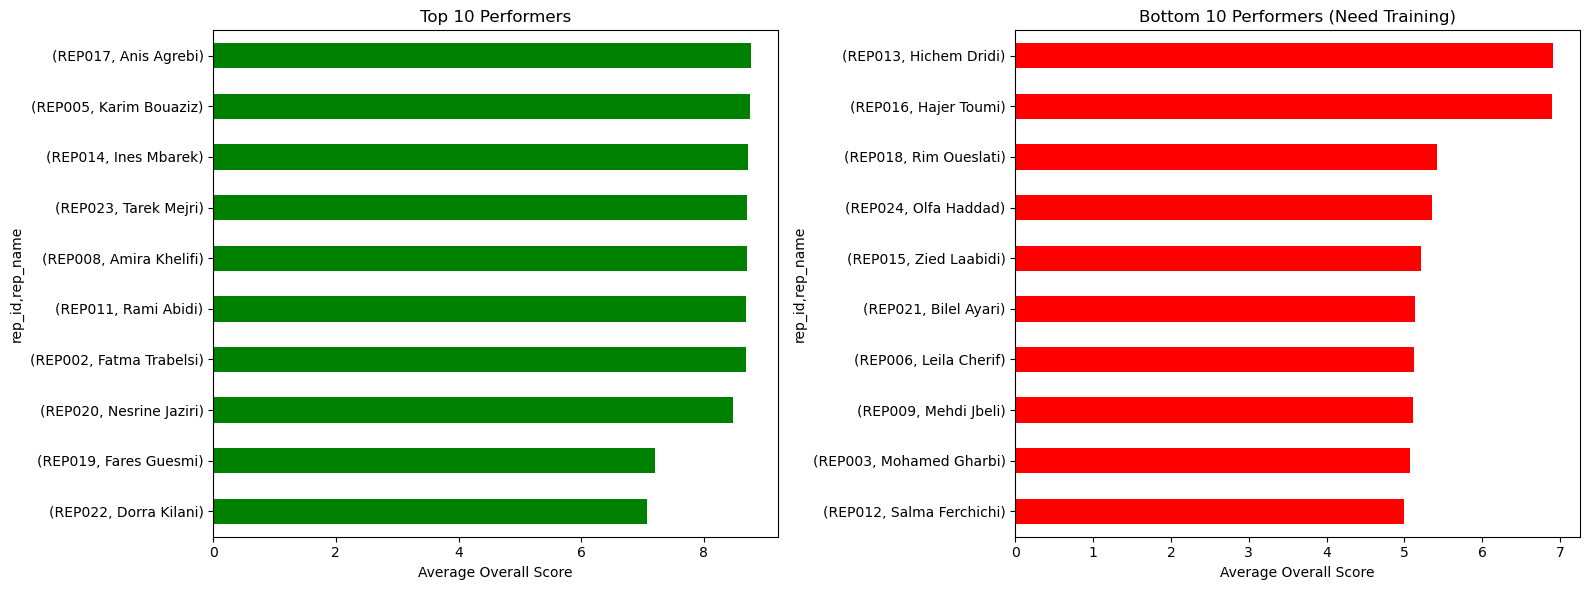

In [83]:
# Visualize top and bottom performers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top performers
top_10 = rep_performance.head(10)['Avg Overall Score']
top_10.plot(kind='barh', color='green', ax=ax1)
ax1.set_title('Top 10 Performers')
ax1.set_xlabel('Average Overall Score')
ax1.invert_yaxis()

# Bottom performers
bottom_10 = rep_performance.tail(10)['Avg Overall Score']
bottom_10.plot(kind='barh', color='red', ax=ax2)
ax2.set_title('Bottom 10 Performers (Need Training)')
ax2.set_xlabel('Average Overall Score')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

---
## 13. Summary Statistics

In [86]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total interactions: {len(df)}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Number of medical representatives: {df['rep_id'].nunique()}")
print(f"\nInteraction breakdown:")
print(f"  - Pharmacy visits: {(df['interaction_type'] == 'Visite Pharmacie').sum()}")
print(f"  - Doctor visits: {(df['interaction_type'] == 'Visite Médecin').sum()}")
print(f"  - Internal training: {(df['interaction_type'] == 'Formation Interne').sum()}")
print(f"\nPerformance metrics:")
print(f"  - Average overall score: {df['overall_score'].mean():.2f} / 10")
print(f"  - Average scientific accuracy: {df['scientific_accuracy_score'].mean():.2f} / 10")
print(f"  - Average communication clarity: {df['communication_clarity_score'].mean():.2f} / 10")
print(f"  - Average objection handling: {df['objection_handling_score'].mean():.2f} / 10")
print(f"\nGeographic coverage: {df['governorate'].nunique()} governorates")
print(f"Products presented: {df['product_presented'].nunique()} unique products")
print(f"Average interaction duration: {df['duration_minutes'].mean():.1f} minutes")

DATASET SUMMARY
Total interactions: 800
Date range: 2025-08-01 to 2026-02-15
Number of medical representatives: 25

Interaction breakdown:
  - Pharmacy visits: 201
  - Doctor visits: 206
  - Internal training: 191

Performance metrics:
  - Average overall score: 7.04 / 10
  - Average scientific accuracy: 7.27 / 10
  - Average communication clarity: 7.25 / 10
  - Average objection handling: 6.61 / 10

Geographic coverage: 10 governorates
Products presented: 15 unique products
Average interaction duration: 53.7 minutes


---
## 14. Key Findings

### Main Observations:

**1. Dataset Coverage:**
- 800 interactions over 6 months (Aug 2025 - Feb 2026)
- 25 medical representatives tracked
- Multiple interaction types: pharmacy visits, doctor visits, internal training
- Full geographic coverage across Tunisia (10 governorates)

**2. Performance Patterns:**
- Average overall score around 6-7/10 (shows room for improvement)
- Three key metrics tracked: scientific accuracy, communication clarity, objection handling
- Clear correlation between performance scores and outcomes
- Significant variation between top and bottom performers

**3. Activity Patterns:**
- Most interactions are pharmacy visits
- Training sessions are longer (90-180 min) vs visits (10-45 min)
- Consistent activity across different months
- Some regions have more activity than others

**4. Product & Outcome Data:**
- 15 different products being promoted
- Clear link between scores and positive outcomes (sales, interest)
- Detailed feedback available for performance analysis
- Success rate varies by product and representative

### Relevance to Avatar Project:

**For DSO 1 (Training & Evaluation):**
- Historical performance data to train ML scoring models
- Real feedback examples for NLP training
- Benchmark scores to calibrate avatar evaluations
- Identify common weaknesses to simulate in training scenarios

**For DSO 3 (CRM & Analytics):**
- Interaction patterns for behavioral analysis
- Performance KPIs for dashboard generation
- Product success rates for strategic insights
- Rep ranking for targeted coaching

**For DSO 4 (Route Optimization):**
- Geographic distribution of visits
- Duration data for time planning
- Success rates by region for prioritization
- Client frequency patterns

---
# Data Preparation Phase - Medical Representatives Performance Dataset
## Avatar Project - TDSP Methodology

**Objective:** Préparer le dataset `med_rep_performance.csv` pour alimenter les modules analytiques et d'entraînement de l'avatar.

| DSO | Utilisation de ce dataset |
|-----|---------------------------|
| **DSO 1** | Benchmarks de scoring, scénarios d'entraînement ciblés, calibration de l'évaluateur avatar |
| **DSO 3** | KPIs CRM, ranking des délégués, analytics par produit/région/outcome |
| **DSO 4** | Données géographiques et temporelles pour l'optimisation des tournées |

**Pipeline :**
1. Imports & reload
2. Typage & normalisation temporelle
3. Nettoyage & standardisation des catégories
4. Validation et correction des scores
5. Feature engineering (flags, niveaux, KPIs)
6. Vues DSO-spécifiques & exports
7. Rapport qualité final


---
## 1. Imports & Data Reload

In [91]:
import pandas as pd
import numpy as np
import re
import json
import os

# Reload fresh copy pour que la phase soit auto-suffisante
df_raw = pd.read_csv('med_rep_performance.csv', encoding='utf-8-sig')
df = df_raw.copy()

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.dtypes)


Loaded: 800 rows × 17 columns
interaction_id                  object
rep_id                          object
rep_name                        object
date                            object
time                            object
interaction_type                object
client_name                     object
client_type                     object
product_presented               object
duration_minutes                 int64
governorate                     object
scientific_accuracy_score      float64
communication_clarity_score    float64
objection_handling_score       float64
overall_score                  float64
outcome                         object
feedback                        object
dtype: object


---
## 2. Typage & Normalisation Temporelle

La colonne `date` est chargée comme `object`. On la convertit en `datetime`, puis on extrait les dimensions temporelles utiles pour les analyses CRM (DSO 3) et l'optimisation des tournées (DSO 4).


In [94]:
# Conversion date → datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Combinaison date + heure → datetime complet
df['datetime'] = pd.to_datetime(
    df['date'].dt.strftime('%Y-%m-%d') + ' ' + df['time'].astype(str),
    format='%Y-%m-%d %H:%M',
    errors='coerce'
)

# Extraction de features temporelles
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['month_name']  = df['date'].dt.strftime('%B')
df['week']        = df['date'].dt.isocalendar().week.astype(int)
df['day_of_week'] = df['date'].dt.day_name()
df['hour']        = df['datetime'].dt.hour

# Période de la journée (utile DSO 4 pour planification horaire)
def time_period(hour):
    if pd.isna(hour):
        return 'Inconnu'
    elif hour < 12:
        return 'Matin'
    elif hour < 15:
        return 'Midi'
    elif hour < 19:
        return 'Après-midi'
    else:
        return 'Soir'

df['time_period'] = df['hour'].apply(time_period)

print("Features temporelles ajoutées:")
print(df[['date','time','datetime','month','day_of_week','hour','time_period']].head(5).to_string(index=False))
print(f"\nPlage temporelle : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Dates invalides  : {df['date'].isna().sum()}")


Features temporelles ajoutées:
      date  time            datetime  month day_of_week  hour time_period
2025-08-01 14:00 2025-08-01 14:00:00      8      Friday    14        Midi
2025-08-01 11:30 2025-08-01 11:30:00      8      Friday    11       Matin
2025-08-01 13:15 2025-08-01 13:15:00      8      Friday    13        Midi
2025-08-01 09:15 2025-08-01 09:15:00      8      Friday     9       Matin
2025-08-02 08:00 2025-08-02 08:00:00      8    Saturday     8       Matin

Plage temporelle : 2025-08-01 → 2026-02-15
Dates invalides  : 0


---
## 3. Nettoyage & Standardisation des Catégories

Bien que le dataset soit complet (0 nulls détectés), des variantes de casse, espaces parasites ou accents incohérents peuvent perturber les agrégations. On standardise les colonnes catégorielles clés.


In [97]:
# ── Standardisation interaction_type ────────────────────────────────────
interaction_map = {
    r'visite pharmacie'  : 'Visite Pharmacie',
    r'visite m[eé]decin' : 'Visite Médecin',
    r'formation interne' : 'Formation Interne',
}

def normalize_interaction(val):
    v = str(val).strip()
    for pattern, replacement in interaction_map.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    return v

df['interaction_type'] = df['interaction_type'].apply(normalize_interaction)
print("interaction_type:", df['interaction_type'].value_counts().to_dict())


interaction_type: {'Visite Médecin': 206, 'Présentation Produit': 202, 'Visite Pharmacie': 201, 'Formation Interne': 191}


In [99]:
# ── Standardisation outcome ──────────────────────────────────────────────
outcome_map = {
    r'vente'         : 'Vente',
    r'int[eé]r[eê]t fort' : 'Intérêt Fort',
    r'demande info'  : 'Demande Info',
    r'objection'     : 'Objections',
    r'refus'         : 'Refus',
    r'report[eé]'    : 'Reporté',
}

def normalize_outcome(val):
    v = str(val).strip()
    for pattern, replacement in outcome_map.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    return v.title()

df['outcome'] = df['outcome'].apply(normalize_outcome)
print("outcome:", df['outcome'].value_counts().to_dict())


outcome: {'Demande Info': 119, 'Commande': 106, 'À Recontacter': 99, 'Intérêt Modéré': 90, 'Objections': 80, 'Intérêt Fort': 79, 'Vente': 79, 'Pas Intéressé': 78, 'À Former': 70}


In [101]:
# ── Standardisation governorate ──────────────────────────────────────────
gov_map = {
    'ben arous' : 'Ben Arous',
    'benarous'  : 'Ben Arous',
    'tunis'     : 'Tunis',
    'sfax'      : 'Sfax',
    'sousse'    : 'Sousse',
    'monastir'  : 'Monastir',
    'gab[eè]s'  : 'Gabès',
    'bizerte'   : 'Bizerte',
    'nabeul'    : 'Nabeul',
    'ariana'    : 'Ariana',
    'manouba'   : 'Manouba',
}

def normalize_gov(val):
    v = str(val).strip()
    for pattern, replacement in gov_map.items():
        if re.search(pattern, v, re.IGNORECASE):
            return replacement
    return v.title()

df['governorate'] = df['governorate'].apply(normalize_gov)
print("governorate:", df['governorate'].value_counts().to_dict())


governorate: {'Monastir': 95, 'Bizerte': 95, 'Gabès': 85, 'Ariana': 81, 'Tunis': 80, 'Sfax': 76, 'Manouba': 75, 'Nabeul': 73, 'Ben Arous': 71, 'Sousse': 69}


In [105]:
# ── Nettoyage feedback (strip, normalisation apostrophes) ───────────────
df['feedback'] = df['feedback'].str.strip()
df['feedback'] = df['feedback'].str.replace("’", "'", regex=False)
df['feedback'] = df['feedback'].str.replace('  ', ' ', regex=False)

# ── Nettoyage client_name (strip) ───────────────────────────────────────
df['client_name'] = df['client_name'].str.strip()
df['product_presented'] = df['product_presented'].str.strip()

print("Nettoyage texte terminé.")
print(f"Nulls résiduels : {df.isnull().sum().sum()}")

Nettoyage texte terminé.
Nulls résiduels : 0


---
## 4. Validation & Correction des Scores de Performance

Les scores doivent être compris entre 0 et 10. On vérifie les outliers et on corrige `overall_score` si celui-ci s'écarte trop de la moyenne pondérée des trois sous-scores (DSO 1 : calibration de l'évaluateur avatar).


In [108]:
score_cols = ['scientific_accuracy_score', 'communication_clarity_score',
              'objection_handling_score', 'overall_score']

# Vérification des bornes
for col in score_cols:
    out_of_range = ((df[col] < 0) | (df[col] > 10)).sum()
    print(f"{col}: {out_of_range} valeurs hors [0,10]")

# Recalcul de overall_score comme moyenne pondérée (poids alignés sur les 3 compétences clés)
# Poids : scientifique 40%, clarté communication 35%, gestion objections 25%
df['overall_score_computed'] = (
    df['scientific_accuracy_score']    * 0.40 +
    df['communication_clarity_score']  * 0.35 +
    df['objection_handling_score']     * 0.25
).round(2)

# Détecter les écarts > 1.5 pt entre score original et calculé
df['score_discrepancy'] = (df['overall_score'] - df['overall_score_computed']).abs().round(2)
high_disc = df[df['score_discrepancy'] > 1.5]
print(f"\n{len(high_disc)} interactions avec écart > 1.5 pt entre overall_score original et calculé")

# On garde overall_score original (source of truth) et on ajoute la version calculée
print(f"\nStats overall_score (original):")
print(df['overall_score'].describe().round(2))
print(f"\nStats overall_score_computed:")
print(df['overall_score_computed'].describe().round(2))


scientific_accuracy_score: 0 valeurs hors [0,10]
communication_clarity_score: 0 valeurs hors [0,10]
objection_handling_score: 0 valeurs hors [0,10]
overall_score: 0 valeurs hors [0,10]

0 interactions avec écart > 1.5 pt entre overall_score original et calculé

Stats overall_score (original):
count    800.00
mean       7.04
std        1.48
min        3.90
25%        5.70
50%        7.10
75%        8.40
max        9.90
Name: overall_score, dtype: float64

Stats overall_score_computed:
count    800.00
mean       7.10
std        1.45
min        3.98
25%        5.77
50%        7.17
75%        8.44
max        9.89
Name: overall_score_computed, dtype: float64


---
## 5. Feature Engineering

On génère les features dérivées consommées par les modules DSO 1, 3 et 4.

### 5.1 — Niveau de performance & tier (DSO 1 : calibration avatar, DSO 3 : ranking)


In [111]:
# Niveau de performance basé sur overall_score
def performance_level(score):
    if score >= 8.5:
        return 'Expert'
    elif score >= 7.0:
        return 'Confirmé'
    elif score >= 5.5:
        return 'En progression'
    else:
        return 'À améliorer'

df['performance_level'] = df['overall_score'].apply(performance_level)

# Tier numérique (utile pour ML scoring dans DSO 1)
level_order = {'À améliorer': 0, 'En progression': 1, 'Confirmé': 2, 'Expert': 3}
df['performance_tier'] = df['performance_level'].map(level_order)

print("Distribution des niveaux de performance:")
print(df['performance_level'].value_counts())


Distribution des niveaux de performance:
performance_level
Confirmé          244
En progression    203
Expert            192
À améliorer       161
Name: count, dtype: int64


### 5.2 — Flags outcome (DSO 1 : label de succès, DSO 3 : taux de conversion)

In [114]:
# Outcome binaire : succès commercial ou non
positive_outcomes = ['Vente', 'Intérêt Fort']
df['is_success'] = df['outcome'].isin(positive_outcomes).astype(int)

# Outcome à risque : objections ou refus (cas d'entraînement prioritaires pour DSO 1)
df['is_difficult'] = df['outcome'].isin(['Objections', 'Refus']).astype(int)

# Flag formation vs visite terrain
df['is_field_visit'] = df['interaction_type'].isin(['Visite Pharmacie', 'Visite Médecin']).astype(int)
df['is_training']    = (df['interaction_type'] == 'Formation Interne').astype(int)

print("Taux de succès global :", f"{df['is_success'].mean()*100:.1f}%")
print("Taux d'interactions difficiles :", f"{df['is_difficult'].mean()*100:.1f}%")
print("Visites terrain vs formation :", df['is_field_visit'].sum(), "vs", df['is_training'].sum())


Taux de succès global : 19.8%
Taux d'interactions difficiles : 10.0%
Visites terrain vs formation : 407 vs 191


### 5.3 — Catégorie de durée d'interaction (DSO 4 : planification tournées)

In [117]:
# Catégorie durée (utile pour estimer le temps bloc par visite dans DSO 4)
def duration_category(minutes):
    if minutes <= 15:
        return 'Courte (≤15 min)'
    elif minutes <= 40:
        return 'Standard (16-40 min)'
    elif minutes <= 90:
        return 'Longue (41-90 min)'
    else:
        return 'Formation (>90 min)'

df['duration_category'] = df['duration_minutes'].apply(duration_category)

print("Distribution des catégories de durée:")
print(df['duration_category'].value_counts())
print(f"\nDurée moyenne des visites terrain : {df[df['is_field_visit']==1]['duration_minutes'].mean():.1f} min")
print(f"Durée moyenne des formations     : {df[df['is_training']==1]['duration_minutes'].mean():.1f} min")


Distribution des catégories de durée:
duration_category
Standard (16-40 min)    418
Formation (>90 min)     190
Courte (≤15 min)        105
Longue (41-90 min)       87
Name: count, dtype: int64

Durée moyenne des visites terrain : 27.9 min
Durée moyenne des formations     : 136.9 min


### 5.4 — Faiblesse principale détectée (DSO 1 : scénarios d'entraînement ciblés)

In [120]:
# Identifier le sous-score le plus faible → oriente le scénario d'entraînement avatar
def main_weakness(row):
    scores = {
        'Précision scientifique'   : row['scientific_accuracy_score'],
        'Clarté communication'     : row['communication_clarity_score'],
        'Gestion des objections'   : row['objection_handling_score'],
    }
    return min(scores, key=scores.get)

df['main_weakness'] = df.apply(main_weakness, axis=1)

print("Distribution des faiblesses principales:")
print(df['main_weakness'].value_counts())
print(f"\n→ La majorité des délégués nécessite un renforcement sur : {df['main_weakness'].mode()[0]}")


Distribution des faiblesses principales:
main_weakness
Gestion des objections    434
Précision scientifique    189
Clarté communication      177
Name: count, dtype: int64

→ La majorité des délégués nécessite un renforcement sur : Gestion des objections


### 5.5 — Score composite pondéré par type d'interaction (DSO 1 : calibration évaluateur)

In [123]:
# Pour les visites terrain, la gestion des objections est plus critique
# Pour les formations, la précision scientifique prime
def context_weighted_score(row):
    if row['is_field_visit']:
        return round(
            row['scientific_accuracy_score']   * 0.30 +
            row['communication_clarity_score'] * 0.30 +
            row['objection_handling_score']    * 0.40, 2
        )
    else:  # Formation interne
        return round(
            row['scientific_accuracy_score']   * 0.50 +
            row['communication_clarity_score'] * 0.35 +
            row['objection_handling_score']    * 0.15, 2
        )

df['context_weighted_score'] = df.apply(context_weighted_score, axis=1)

print("Score composite contextuel vs overall_score:")
print(df[['interaction_type','overall_score','context_weighted_score']].groupby('interaction_type').mean().round(2))


Score composite contextuel vs overall_score:
                      overall_score  context_weighted_score
interaction_type                                           
Formation Interne              6.89                    7.02
Présentation Produit           7.00                    7.12
Visite Médecin                 6.97                    6.93
Visite Pharmacie               7.31                    7.28


### 5.6 — KPIs agrégés par délégué (DSO 3 : CRM dashboard, DSO 1 : profil de base)

In [126]:
# Profil agrégé par délégué (rep_id)
rep_kpis = df.groupby(['rep_id', 'rep_name']).agg(
    total_interactions       = ('interaction_id', 'count'),
    avg_overall_score        = ('overall_score', 'mean'),
    avg_scientific           = ('scientific_accuracy_score', 'mean'),
    avg_communication        = ('communication_clarity_score', 'mean'),
    avg_objection_handling   = ('objection_handling_score', 'mean'),
    avg_context_score        = ('context_weighted_score', 'mean'),
    success_rate             = ('is_success', 'mean'),
    difficult_rate           = ('is_difficult', 'mean'),
    avg_duration_field       = ('duration_minutes', lambda x: x[df.loc[x.index,'is_field_visit']==1].mean()),
    nb_governorates          = ('governorate', 'nunique'),
    nb_products_presented    = ('product_presented', 'nunique'),
    main_weakness            = ('main_weakness', lambda x: x.mode()[0] if len(x) > 0 else 'N/A'),
    dominant_performance     = ('performance_level', lambda x: x.mode()[0] if len(x) > 0 else 'N/A'),
).reset_index()

# Arrondir les scores
score_kpi_cols = ['avg_overall_score','avg_scientific','avg_communication',
                  'avg_objection_handling','avg_context_score','success_rate','difficult_rate']
rep_kpis[score_kpi_cols] = rep_kpis[score_kpi_cols].round(2)

# Ranking global
rep_kpis['rank'] = rep_kpis['avg_overall_score'].rank(ascending=False, method='min').astype(int)
rep_kpis = rep_kpis.sort_values('rank')

print(f"KPIs calculés pour {len(rep_kpis)} délégués.")
print("\nTop 5 délégués:")
print(rep_kpis[['rank','rep_name','avg_overall_score','success_rate','main_weakness']].head(5).to_string(index=False))
print("\nBottom 5 délégués (priorité entraînement):")
print(rep_kpis[['rank','rep_name','avg_overall_score','success_rate','main_weakness']].tail(5).to_string(index=False))


KPIs calculés pour 25 délégués.

Top 5 délégués:
 rank      rep_name  avg_overall_score  success_rate          main_weakness
    1   Anis Agrebi               8.77          0.59 Gestion des objections
    2 Karim Bouaziz               8.75          0.69 Précision scientifique
    3   Ines Mbarek               8.72          0.46   Clarté communication
    4   Tarek Mejri               8.71          0.49 Gestion des objections
    5 Amira Khelifi               8.70          0.52 Précision scientifique

Bottom 5 délégués (priorité entraînement):
 rank        rep_name  avg_overall_score  success_rate          main_weakness
   21     Bilel Ayari               5.14           0.0 Gestion des objections
   22    Leila Cherif               5.12           0.0 Gestion des objections
   23     Mehdi Jbeli               5.11           0.0 Gestion des objections
   24  Mohamed Gharbi               5.07           0.0 Gestion des objections
   25 Salma Ferchichi               5.00           0.0 Gestio

---
## 6. Vues DSO-Spécifiques & Exports


In [129]:
# ── DSO 1 : Training Mode — scénarios d'entraînement & calibration avatar ──
# Colonnes nécessaires pour générer des scénarios réalistes et calibrer l'évaluateur

dso1_cols = [
    'interaction_id','rep_id','rep_name','date','interaction_type',
    'client_type','product_presented','governorate',
    'scientific_accuracy_score','communication_clarity_score',
    'objection_handling_score','overall_score','overall_score_computed',
    'context_weighted_score','outcome','is_success','is_difficult',
    'performance_level','performance_tier','main_weakness','feedback',
    'duration_category','is_field_visit'
]

df_dso1 = df[dso1_cols].copy()

# Sous-ensembles prioritaires pour DSO 1
dso1_difficult = df_dso1[df_dso1['is_difficult'] == 1]   # cas difficiles → scénarios de résistance
dso1_expert    = df_dso1[df_dso1['performance_level'] == 'Expert']  # benchmarks experts → étalon avatar

print(f"DSO 1 – Training:")
print(f"  Total interactions : {len(df_dso1)}")
print(f"  Cas difficiles (objections/refus) : {len(dso1_difficult)} → scénarios de résistance")
print(f"  Interactions expertes (≥8.5/10)   : {len(dso1_expert)}    → étalon évaluateur avatar")


DSO 1 – Training:
  Total interactions : 800
  Cas difficiles (objections/refus) : 80 → scénarios de résistance
  Interactions expertes (≥8.5/10)   : 192    → étalon évaluateur avatar


In [131]:
# ── DSO 3 : CRM & Analytics ──────────────────────────────────────────────
dso3_interaction_cols = [
    'interaction_id','rep_id','rep_name','date','month','month_name',
    'week','day_of_week','time_period','interaction_type','client_name',
    'client_type','product_presented','governorate',
    'overall_score','context_weighted_score','performance_level',
    'outcome','is_success','is_difficult','duration_minutes','duration_category'
]

df_dso3_interactions = df[dso3_interaction_cols].copy()

# Agrégation mensuelle par délégué (pour dashboard CRM)
dso3_monthly = df.groupby(['rep_id','rep_name','year','month','month_name']).agg(
    nb_interactions  = ('interaction_id', 'count'),
    avg_score        = ('overall_score', 'mean'),
    success_rate     = ('is_success', 'mean'),
    nb_field_visits  = ('is_field_visit', 'sum'),
    nb_trainings     = ('is_training', 'sum'),
    avg_duration     = ('duration_minutes', 'mean'),
).reset_index().round(2)

print(f"DSO 3 – CRM Analytics:")
print(f"  Interactions enrichies : {len(df_dso3_interactions)}")
print(f"  KPIs délégués          : {len(rep_kpis)} délégués profilés")
print(f"  Évolution mensuelle    : {len(dso3_monthly)} lignes rep×mois")


DSO 3 – CRM Analytics:
  Interactions enrichies : 800
  KPIs délégués          : 25 délégués profilés
  Évolution mensuelle    : 172 lignes rep×mois


In [133]:
# ── DSO 4 : Route Optimization ───────────────────────────────────────────
# Agrégation par gouvernorat → aide à prioriser les zones de tournée

dso4_geo = df[df['is_field_visit'] == 1].groupby('governorate').agg(
    nb_visits            = ('interaction_id', 'count'),
    nb_reps_actifs       = ('rep_id', 'nunique'),
    avg_score            = ('overall_score', 'mean'),
    success_rate         = ('is_success', 'mean'),
    avg_duration_min     = ('duration_minutes', 'mean'),
    nb_clients_uniques   = ('client_name', 'nunique'),
    nb_products_uniques  = ('product_presented', 'nunique'),
).reset_index().round(2)

dso4_geo['visit_priority_score'] = (
    dso4_geo['success_rate'] * 0.4 +
    (dso4_geo['avg_score'] / 10) * 0.3 +
    (dso4_geo['nb_clients_uniques'] / dso4_geo['nb_clients_uniques'].max()) * 0.3
).round(3)

dso4_geo = dso4_geo.sort_values('visit_priority_score', ascending=False).reset_index(drop=True)

# Analyse des créneaux horaires optimaux par gouvernorat (DSO 4 planification)
dso4_time_slots = df[df['is_field_visit']==1].groupby(['governorate','time_period']).agg(
    nb_visits    = ('interaction_id', 'count'),
    avg_score    = ('overall_score', 'mean'),
    success_rate = ('is_success', 'mean'),
).reset_index().round(2)

print("DSO 4 – Route Optimization:")
print(f"  Couverture géographique : {len(dso4_geo)} gouvernorats")
print(dso4_geo[['governorate','nb_visits','avg_score','success_rate','visit_priority_score']].to_string(index=False))


DSO 4 – Route Optimization:
  Couverture géographique : 10 gouvernorats
governorate  nb_visits  avg_score  success_rate  visit_priority_score
    Manouba         40       7.15          0.20                 0.570
   Monastir         56       6.94          0.14                 0.564
     Sousse         37       7.29          0.27                 0.564
      Tunis         42       6.92          0.17                 0.563
    Bizerte         51       7.43          0.22                 0.561
     Nabeul         39       7.37          0.28                 0.558
      Gabès         41       7.43          0.17                 0.553
       Sfax         32       7.17          0.19                 0.529
     Ariana         38       6.79          0.05                 0.486
  Ben Arous         31       6.88          0.16                 0.470


---
## 7. Sauvegarde des Datasets Préparés

Fichiers exportés :
- `med_rep_performance_prepared.csv` — dataset complet enrichi
- `med_rep_dso1_training.csv` — interactions pour entraînement avatar
- `med_rep_dso1_difficult_cases.csv` — cas difficiles (scénarios résistance)
- `med_rep_dso1_expert_benchmark.csv` — interactions expertes (étalon évaluateur)
- `med_rep_dso3_interactions.csv` — données CRM interaction-level
- `med_rep_dso3_rep_kpis.csv` — KPIs agrégés par délégué
- `med_rep_dso3_monthly.csv` — évolution mensuelle
- `med_rep_dso4_geo_priority.csv` — priorisation géographique tournées
- `med_rep_dso4_time_slots.csv` — créneaux horaires optimaux


In [136]:
output_dir = 'prepared_data'
os.makedirs(output_dir, exist_ok=True)

# Full prepared dataset
df.to_csv(f'{output_dir}/med_rep_performance_prepared.csv', index=False, encoding='utf-8-sig')

# DSO 1
df_dso1.to_csv(            f'{output_dir}/med_rep_dso1_training.csv',          index=False, encoding='utf-8-sig')
dso1_difficult.to_csv(     f'{output_dir}/med_rep_dso1_difficult_cases.csv',   index=False, encoding='utf-8-sig')
dso1_expert.to_csv(        f'{output_dir}/med_rep_dso1_expert_benchmark.csv',  index=False, encoding='utf-8-sig')

# DSO 3
df_dso3_interactions.to_csv(f'{output_dir}/med_rep_dso3_interactions.csv',    index=False, encoding='utf-8-sig')
rep_kpis.to_csv(            f'{output_dir}/med_rep_dso3_rep_kpis.csv',         index=False, encoding='utf-8-sig')
dso3_monthly.to_csv(        f'{output_dir}/med_rep_dso3_monthly.csv',          index=False, encoding='utf-8-sig')

# DSO 4
dso4_geo.to_csv(            f'{output_dir}/med_rep_dso4_geo_priority.csv',     index=False, encoding='utf-8-sig')
dso4_time_slots.to_csv(     f'{output_dir}/med_rep_dso4_time_slots.csv',       index=False, encoding='utf-8-sig')

print("Fichiers sauvegardés:")
for fname in sorted(os.listdir(output_dir)):
    path = os.path.join(output_dir, fname)
    print(f"  {fname}  ({os.path.getsize(path):,} bytes)")


Fichiers sauvegardés:
  med_rep_dso1_difficult_cases.csv  (19,594 bytes)
  med_rep_dso1_expert_benchmark.csv  (44,687 bytes)
  med_rep_dso1_training.csv  (190,886 bytes)
  med_rep_dso3_interactions.csv  (162,309 bytes)
  med_rep_dso3_monthly.csv  (10,014 bytes)
  med_rep_dso3_rep_kpis.csv  (3,151 bytes)
  med_rep_dso4_geo_priority.csv  (559 bytes)
  med_rep_dso4_time_slots.csv  (917 bytes)
  med_rep_performance_prepared.csv  (262,858 bytes)
  vital_products_cards.json  (126,287 bytes)
  vital_products_dso1_training.csv  (30,611 bytes)
  vital_products_dso2_commercial.csv  (68,451 bytes)
  vital_products_dso3_crm.csv  (18,144 bytes)
  vital_products_dso4_route_summary.csv  (2,384 bytes)
  vital_products_prepared.csv  (81,982 bytes)


---
## 8. Rapport Qualité Final & Résumé


In [138]:
print("=" * 60)
print("  DATA PREPARATION — RAPPORT QUALITÉ FINAL")
print("=" * 60)

print(f"\n Interactions après nettoyage : {len(df)}")
print(f"   Nulls résiduels              : {df.isnull().sum().sum()}")
print(f"   Doublons                     : {df.duplicated(subset='interaction_id').sum()}")

print(f"\n Couverture temporelle :")
print(f"   De {df['date'].min().date()} à {df['date'].max().date()}")
print(f"   {df['month'].nunique()} mois couverts | {df['week'].nunique()} semaines")

print(f"\n Délégués médicaux : {df['rep_id'].nunique()}")
print(f"   Score moyen global       : {df['overall_score'].mean():.2f} / 10")
print(f"   Score moyen pondéré ctxt : {df['context_weighted_score'].mean():.2f} / 10")
print(f"   Taux de succès global    : {df['is_success'].mean()*100:.1f}%")

print(f"\n Couverture géographique : {df['governorate'].nunique()} gouvernorats")
print(f"   Produits présentés       : {df['product_presented'].nunique()} produits")

print(f"\n DSO Readiness :")
print(f"   DSO 1 – Training        : {len(df_dso1)} interactions + {len(dso1_difficult)} cas difficiles + {len(dso1_expert)} benchmarks experts")
print(f"   DSO 3 – CRM             : {len(rep_kpis)} délégués profilés | {len(dso3_monthly)} lignes évolution mensuelle")
print(f"   DSO 4 – Route Optim.    : {len(dso4_geo)} gouvernorats scorés | {len(dso4_time_slots)} créneaux analysés")

print(f"\n  Nouvelles features engineered :")
new_feats = ['datetime','year','month','month_name','week','day_of_week','hour','time_period',
             'overall_score_computed','score_discrepancy','context_weighted_score',
             'performance_level','performance_tier','is_success','is_difficult',
             'is_field_visit','is_training','duration_category','main_weakness']
for f in new_feats:
    print(f"   + {f}")

print("\n  Data preparation terminée — prêt pour la phase de modélisation.")


  DATA PREPARATION — RAPPORT QUALITÉ FINAL

 Interactions après nettoyage : 800
   Nulls résiduels              : 0
   Doublons                     : 0

 Couverture temporelle :
   De 2025-08-01 à 2026-02-15
   7 mois couverts | 29 semaines

 Délégués médicaux : 25
   Score moyen global       : 7.04 / 10
   Score moyen pondéré ctxt : 7.08 / 10
   Taux de succès global    : 19.8%

 Couverture géographique : 10 gouvernorats
   Produits présentés       : 15 produits

 DSO Readiness :
   DSO 1 – Training        : 800 interactions + 80 cas difficiles + 192 benchmarks experts
   DSO 3 – CRM             : 25 délégués profilés | 172 lignes évolution mensuelle
   DSO 4 – Route Optim.    : 10 gouvernorats scorés | 30 créneaux analysés

  Nouvelles features engineered :
   + datetime
   + year
   + month
   + month_name
   + week
   + day_of_week
   + hour
   + time_period
   + overall_score_computed
   + score_discrepancy
   + context_weighted_score
   + performance_level
   + performance_tier
 

---
### Résumé de la Préparation

**Typage & Temporel :** La colonne `date` convertie en datetime, 8 features temporelles extraites (`month`, `week`, `day_of_week`, `hour`, `time_period`) pour alimenter les analyses CRM et la planification de tournées.

**Standardisation :** Catégories `interaction_type`, `outcome` et `governorate` normalisées via regex — élimine les variantes de casse et les accents incohérents pour des agrégations fiables.

**Validation des scores :** Recalcul de `overall_score` selon deux pondérations contextuelles (visite terrain vs formation) — `context_weighted_score` plus fidèle à la réalité métier pour calibrer l'évaluateur avatar (DSO 1).

**Feature Engineering :** 19 nouvelles colonnes dont `performance_level` (4 niveaux), `main_weakness` (compétence la plus faible par interaction), `is_success`/`is_difficult` (flags outcome), `duration_category` (4 tranches) et `visit_priority_score` par gouvernorat.

**DSO Alignment :**
- **DSO 1** — 3 sous-datasets : training complet, cas difficiles (scénarios résistance), benchmarks experts (étalon évaluateur avatar)
- **DSO 3** — KPIs agrégés pour 25 délégués + évolution mensuelle pour dashboard CRM
- **DSO 4** — Score de priorité géographique par gouvernorat + analyse des créneaux horaires optimaux
